# ClearBank - Análise Financeira com Python

Este notebook resolve o desafio final de análise financeira da fintech ClearBank.

A solução usa Python puro para ler e validar um arquivo `transacoes.csv`, agrupar os dados por mês, calcular métricas financeiras, sinalizar transações suspeitas e exportar o resultado em `relatorio.json`.

## Estrutura esperada do CSV

O arquivo `transacoes.csv` deve conter as colunas:

- `id`
- `data`
- `cliente_id`
- `tipo`
- `valor`
- `descricao`
- `categoria`

## Regras principais

- O CSV é lido com o módulo nativo `csv`, sem `pandas` na solução principal.
- Linhas inválidas são descartadas sem interromper o programa.
- Transações acima de R$ 10.000,00 são marcadas como suspeitas.
- O relatório é exibido de forma formatada e salvo em JSON.


## 1. Criando o arquivo `transacoes.csv` para teste

Esta célula cria um CSV de exemplo com:

- 15 registros válidos;
- 5 registros inválidos;
- dados distribuídos em 4 meses;
- 2 transações acima de R$ 10.000,00.


In [1]:
conteudo_csv = """id,data,cliente_id,tipo,valor,descricao,categoria
1,2026-01-05,CLI001,credito,3500.00,Salário janeiro,salario
2,2026-01-12,CLI002,debito,180.50,Supermercado,compra
3,2026-01-20,CLI001,debito,220.15,Farmácia,saude
4,2026-01-27,CLI004,debito,89.90,Transporte,transporte
5,2026-02-03,CLI003,credito,15000.00,Transferência suspeita,transferencia
6,2026-02-08,CLI002,debito,320.00,Conta de luz,conta
7,2026-02-14,CLI005,debito,890.00,Aluguel,moradia
8,2026-02-25,CLI001,credito,3500.00,Salário fevereiro,salario
9,2026-03-01,CLI001,credito,3500.00,Salário março,salario
10,2026-03-10,CLI003,debito,99.90,Streaming,assinatura
11,2026-03-17,CLI006,debito,450.00,Compra online,compra
12,2026-03-29,CLI002,credito,1800.00,Freelance,renda_extra
13,2026-04-02,CLI004,debito,250.00,Manutenção,servico
14,2026-04-12,CLI007,credito,12000.00,Bônus anual,bonus
15,2026-04-20,CLI001,debito,650.00,Curso online,educacao
16,2026-04-21,,debito,100.00,Sem cliente,transferencia
ABC,2026-04-22,CLI008,credito,500.00,ID inválido,renda_extra
17,2026/04/25,CLI009,debito,75.00,Data inválida,compra
18,2026-04-28,CLI010,saque,300.00,Tipo inválido,outros
19,2026-04-29,CLI011,credito,abc,Valor inválido,outros
"""

with open("transacoes.csv", "w", encoding="utf-8", newline="") as arquivo:
    arquivo.write(conteudo_csv)

print("Arquivo transacoes.csv criado com sucesso.")

Arquivo transacoes.csv criado com sucesso.


## 2. Importações e constantes

In [2]:
import csv
import json
from datetime import datetime, date

ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
ARQUIVO_GRAFICO = "grafico.png"
LIMITE_SUSPEITO = 10000.00

## 3. Funções auxiliares

As funções abaixo separam responsabilidades: formatação, leitura, validação, geração do relatório, exportação em JSON, exibição no terminal e geração do gráfico.

In [3]:
def formatar_moeda(valor):
    """Formata um número como moeda brasileira."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def ler_transacoes(caminho_csv):
    """Lê o arquivo CSV e retorna uma lista de transações brutas."""
    try:
        with open(caminho_csv, mode="r", encoding="utf-8-sig", newline="") as arquivo:
            leitor = csv.DictReader(arquivo)
            return list(leitor)
    except FileNotFoundError:
        print(f"Erro: o arquivo {caminho_csv} não foi encontrado.")
        return []


def validar_transacao(linha):
    """Valida uma linha do CSV e retorna uma transação limpa ou None."""
    id_texto = linha.get("id", "").strip()
    data_texto = linha.get("data", "").strip()
    cliente_id = linha.get("cliente_id", "").strip()
    tipo = linha.get("tipo", "").strip().lower()
    valor_texto = linha.get("valor", "").strip()
    descricao = linha.get("descricao", "").strip()
    categoria = linha.get("categoria", "").strip()

    if not id_texto.isdigit():
        return None

    if not cliente_id:
        return None

    try:
        data_objeto = datetime.strptime(data_texto, "%Y-%m-%d")
    except ValueError:
        return None

    if tipo not in ["credito", "debito"]:
        return None

    try:
        valor = float(valor_texto)
    except ValueError:
        return None

    if valor <= 0:
        return None

    return {
        "id": int(id_texto),
        "data": data_objeto,
        "data_texto": data_objeto.strftime("%Y-%m-%d"),
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": round(valor, 2),
        "descricao": descricao,
        "categoria": categoria,
    }


def limpar_transacoes(transacoes_brutas):
    """Valida todas as transações brutas e separa válidas e inválidas."""
    transacoes_validas = []
    total_invalidas = 0

    for linha in transacoes_brutas:
        transacao = validar_transacao(linha)

        if transacao is None:
            total_invalidas += 1
        else:
            transacoes_validas.append(transacao)

    return transacoes_validas, total_invalidas


def gerar_relatorio(transacoes_validas, total_linhas_lidas, total_invalidas):
    """Agrupa os dados por mês, calcula métricas e retorna o relatório final."""
    resumo_mensal = {}
    transacoes_suspeitas = []

    for transacao in transacoes_validas:
        mes = transacao["data"].strftime("%Y-%m")
        valor = transacao["valor"]

        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "saldo": 0.0,
                "media": 0.0,
                "maior_valor": valor,
                "menor_valor": valor,
                "maior_transacao": transacao,
                "menor_transacao": transacao,
            }

        resumo = resumo_mensal[mes]
        resumo["quantidade"] += 1

        if transacao["tipo"] == "credito":
            resumo["total_credito"] += valor
        else:
            resumo["total_debito"] += valor

        if valor > resumo["maior_valor"]:
            resumo["maior_valor"] = valor
            resumo["maior_transacao"] = transacao

        if valor < resumo["menor_valor"]:
            resumo["menor_valor"] = valor
            resumo["menor_transacao"] = transacao

        if valor > LIMITE_SUSPEITO:
            transacoes_suspeitas.append({
                "id": transacao["id"],
                "cliente_id": transacao["cliente_id"],
                "data": transacao["data_texto"],
                "valor": valor,
            })

    resumo_mensal_json = {}

    for mes in sorted(resumo_mensal):
        resumo = resumo_mensal[mes]
        total_mes = resumo["total_credito"] + resumo["total_debito"]
        resumo["saldo"] = resumo["total_credito"] - resumo["total_debito"]
        resumo["media"] = total_mes / resumo["quantidade"]

        resumo_mensal_json[mes] = {
            "quantidade": resumo["quantidade"],
            "total_credito": round(resumo["total_credito"], 2),
            "total_debito": round(resumo["total_debito"], 2),
            "saldo": round(resumo["saldo"], 2),
            "media": round(resumo["media"], 2),
            "maior_valor": round(resumo["maior_valor"], 2),
            "menor_valor": round(resumo["menor_valor"], 2),
            "maior_transacao_id": resumo["maior_transacao"]["id"],
            "menor_transacao_id": resumo["menor_transacao"]["id"],
        }

    if transacoes_validas:
        data_mais_antiga = min(t["data"] for t in transacoes_validas).date()
        data_mais_recente = max(t["data"] for t in transacoes_validas).date()
        hoje = date.today()

        periodo_analisado = {
            "data_mais_antiga": data_mais_antiga.isoformat(),
            "data_mais_recente": data_mais_recente.isoformat(),
            "dias_entre_primeira_e_ultima": (data_mais_recente - data_mais_antiga).days,
            "dias_desde_transacao_mais_antiga": (hoje - data_mais_antiga).days,
            "dias_desde_transacao_mais_recente": (hoje - data_mais_recente).days,
        }
    else:
        periodo_analisado = {
            "data_mais_antiga": None,
            "data_mais_recente": None,
            "dias_entre_primeira_e_ultima": 0,
            "dias_desde_transacao_mais_antiga": 0,
            "dias_desde_transacao_mais_recente": 0,
        }

    return {
        "gerado_em": date.today().isoformat(),
        "total_linhas_lidas": total_linhas_lidas,
        "total_transacoes_validas": len(transacoes_validas),
        "total_transacoes_invalidas": total_invalidas,
        "periodo_analisado": periodo_analisado,
        "resumo_mensal": resumo_mensal_json,
        "transacoes_suspeitas": transacoes_suspeitas,
    }


def salvar_json(relatorio, caminho_json):
    """Salva o relatório final em um arquivo JSON."""
    with open(caminho_json, mode="w", encoding="utf-8") as arquivo:
        json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)



def exibir_relatorio(relatorio):
    """Exibe o relatório no terminal de forma organizada."""
    periodo = relatorio["periodo_analisado"]

    print("===== RESUMO DA LIMPEZA =====")
    print(f"Total de linhas lidas: {relatorio['total_linhas_lidas']}")
    print(f"Linhas válidas: {relatorio['total_transacoes_validas']}")
    print(f"Linhas inválidas: {relatorio['total_transacoes_invalidas']}")

    print("\n===== PERÍODO ANALISADO =====")
    print(f"Data mais antiga: {periodo['data_mais_antiga']}")
    print(f"Data mais recente: {periodo['data_mais_recente']}")
    print(f"Dias entre a primeira e a última transação: {periodo['dias_entre_primeira_e_ultima']}")
    print(f"Dias desde a transação mais antiga: {periodo['dias_desde_transacao_mais_antiga']}")
    print(f"Dias desde a transação mais recente: {periodo['dias_desde_transacao_mais_recente']}")

    print("\n===== RELATÓRIO MENSAL =====")

    for mes, resumo in relatorio["resumo_mensal"].items():
        print(f"\nMês: {mes}")
        print(f"  Transações:   {resumo['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(resumo['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(resumo['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(resumo['saldo'])}")
        print(f"  Média:         {formatar_moeda(resumo['media'])}")
        print(f"  Maior valor:   {formatar_moeda(resumo['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(resumo['menor_valor'])}")

    print("\n===== TRANSAÇÕES SUSPEITAS =====")

    if not relatorio["transacoes_suspeitas"]:
        print("Nenhuma transação suspeita encontrada.")
    else:
        for transacao in relatorio["transacoes_suspeitas"]:
            print(
                f"ID: {transacao['id']} | "
                f"Cliente: {transacao['cliente_id']} | "
                f"Data: {transacao['data']} | "
                f"Valor: {formatar_moeda(transacao['valor'])}"
            )


def gerar_grafico_saldo(relatorio, caminho_grafico):
    """Gera um gráfico de barras com o saldo mensal."""
    import matplotlib.pyplot as plt

    meses = list(relatorio["resumo_mensal"].keys())
    saldos = [dados["saldo"] for dados in relatorio["resumo_mensal"].values()]

    plt.figure(figsize=(8, 5))
    plt.bar(meses, saldos, label="Saldo mensal")
    plt.title("Saldo mensal - ClearBank")
    plt.xlabel("Mês")
    plt.ylabel("Saldo em R$")
    plt.legend()
    plt.tight_layout()
    plt.savefig(caminho_grafico)
    plt.show()


## 4. Teste rápido da leitura e validação

In [4]:
transacoes_brutas_teste = ler_transacoes(ARQUIVO_CSV)
transacoes_validas_teste, total_invalidas_teste = limpar_transacoes(transacoes_brutas_teste)

print(f"Linhas lidas no teste: {len(transacoes_brutas_teste)}")
print(f"Transações válidas no teste: {len(transacoes_validas_teste)}")
print(f"Transações inválidas no teste: {total_invalidas_teste}")
print("\nPrimeira transação válida:")
print(transacoes_validas_teste[0])

Linhas lidas no teste: 20
Transações válidas no teste: 15
Transações inválidas no teste: 5

Primeira transação válida:
{'id': 1, 'data': datetime.datetime(2026, 1, 5, 0, 0), 'data_texto': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': 3500.0, 'descricao': 'Salário janeiro', 'categoria': 'salario'}


## 5. Célula de execução principal

Esta célula executa todo o fluxo do projeto:

1. Lê o CSV;
2. Valida e limpa as linhas;
3. Gera o relatório mensal;
4. Exibe o relatório formatado;
5. Salva o resultado em `relatorio.json`.

In [5]:
transacoes_brutas = ler_transacoes(ARQUIVO_CSV)
transacoes_validas, total_invalidas = limpar_transacoes(transacoes_brutas)

relatorio = gerar_relatorio(
    transacoes_validas=transacoes_validas,
    total_linhas_lidas=len(transacoes_brutas),
    total_invalidas=total_invalidas,
)

exibir_relatorio(relatorio)
salvar_json(relatorio, ARQUIVO_JSON)

print(f"\nArquivo {ARQUIVO_JSON} salvo com sucesso.")

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 20
Linhas válidas: 15
Linhas inválidas: 5

===== PERÍODO ANALISADO =====
Data mais antiga: 2026-01-05
Data mais recente: 2026-04-20
Dias entre a primeira e a última transação: 105
Dias desde a transação mais antiga: 159
Dias desde a transação mais recente: 54

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:   4
  Total crédito: R$ 3.500,00
  Total débito:  R$ 490,55
  Saldo:         R$ 3.009,45
  Média:         R$ 997,64
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 89,90

Mês: 2026-02
  Transações:   4
  Total crédito: R$ 18.500,00
  Total débito:  R$ 1.210,00
  Saldo:         R$ 17.290,00
  Média:         R$ 4.927,50
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 320,00

Mês: 2026-03
  Transações:   4
  Total crédito: R$ 5.300,00
  Total débito:  R$ 549,90
  Saldo:         R$ 4.750,10
  Média:         R$ 1.462,47
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 99,90

Mês: 2026-04
  Transações:   3
  Total crédito: R

## 6. Conferindo o JSON gerado

In [6]:
with open(ARQUIVO_JSON, mode="r", encoding="utf-8") as arquivo:
    relatorio_json = json.load(arquivo)

print(json.dumps(relatorio_json, ensure_ascii=False, indent=2))

{
  "gerado_em": "2026-06-13",
  "total_linhas_lidas": 20,
  "total_transacoes_validas": 15,
  "total_transacoes_invalidas": 5,
  "periodo_analisado": {
    "data_mais_antiga": "2026-01-05",
    "data_mais_recente": "2026-04-20",
    "dias_entre_primeira_e_ultima": 105,
    "dias_desde_transacao_mais_antiga": 159,
    "dias_desde_transacao_mais_recente": 54
  },
  "resumo_mensal": {
    "2026-01": {
      "quantidade": 4,
      "total_credito": 3500.0,
      "total_debito": 490.55,
      "saldo": 3009.45,
      "media": 997.64,
      "maior_valor": 3500.0,
      "menor_valor": 89.9,
      "maior_transacao_id": 1,
      "menor_transacao_id": 4
    },
    "2026-02": {
      "quantidade": 4,
      "total_credito": 18500.0,
      "total_debito": 1210.0,
      "saldo": 17290.0,
      "media": 4927.5,
      "maior_valor": 15000.0,
      "menor_valor": 320.0,
      "maior_transacao_id": 5,
      "menor_transacao_id": 6
    },
    "2026-03": {
      "quantidade": 4,
      "total_credito": 5300

## 7. Requisito opcional: gráfico com matplotlib

A célula abaixo gera o arquivo `grafico.png` com o saldo mensal.

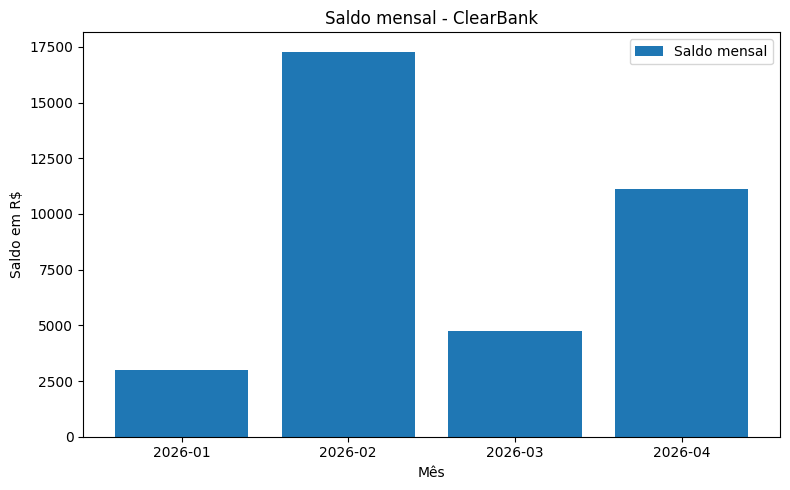

Arquivo grafico.png salvo com sucesso.


In [7]:
gerar_grafico_saldo(relatorio, ARQUIVO_GRAFICO)
print(f"Arquivo {ARQUIVO_GRAFICO} salvo com sucesso.")